# LLM Workshop Code Along

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fryan2503/llm_workshop/blob/main/presentation_code_along.ipynb)

This notebook mirrors `presentation.qmd` and gives runnable demos for each section.

## Add your key to Colab Secrets

Add your API key to the Colab Secrets manager to securely store it.

1. Open your Google Colab notebook and click on the 🔑 **Secrets** tab in the left panel.
   
   <img src="https://storage.googleapis.com/generativeai-downloads/images/secrets.jpg" alt="You can find the Secrets tab on the left panel." width=50%>

2. Create 2 new secret keys with the names `OPENAI_API_KEY_EMBEDDINGS` & `OPENAI_API_KEY_RESPONSES` .
3. Copy and paste your API key into the `Value` input box of each secret key.
4. Toggle the button on the left to allow all notebooks access to the secret.


You create a client using your API key, but instead of pasting your key into the notebook, you'll read it from Colab Secrets thanks to `userdata`.

> MASSIVE shoutout to Fadel for giving us the API key.

In [2]:
# ── Colab Setup ──────────────────────────────────────────────────────────────
# Run this cell first if you are on Google Colab

import sys
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import userdata

    embedding_api_key=userdata.get("OPENAI_API_KEY_EMBEDDINGS")

    response_api_key=userdata.get("OPENAI_API_KEY_RESPONSES")



### Copying over files from repo

In [3]:
if IN_COLAB:
    !pip install -q openai tiktoken numpy pandas sentence-transformers \
        langchain-core langchain-community langchain-openai langchain-nomic \
        langgraph faiss-cpu

    # Clone repo to get data/ and vstore/ directories
    !git clone --depth 1 https://github.com/fryan2503/llm_workshop.git _repo
    import shutil, os
    for folder in ["data", "vstore"]:
        if not os.path.exists(folder):
            shutil.copytree(f"_repo/{folder}", folder)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 2.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.
Cloning into '_repo'...
remote: Enumerating objects: 132, done.
remote: Counting objects: 100% (132/132)

In [4]:
import os                          # File system operations (read env vars, paths)
import json                        # Parse JSON data files (art collection, golden set)
import random                      # Reproducible random sampling
import sqlite3                     # In-memory SQL database for structured queries
from typing import TypedDict, Annotated, List  # Type hints for LangGraph state

import tiktoken                    # OpenAI's tokenizer — count and inspect tokens
import numpy as np                 # Numerical operations (cosine similarity, softmax)
import pandas as pd                # DataFrames for eval results
from langchain_core.messages import HumanMessage, AnyMessage  # LangChain message types
from langgraph.graph.message import add_messages              # LangGraph state reducer
from openai import OpenAI          # Native OpenAI API client

random.seed(42)                    # Fix random seed for reproducibility

# Agenda

1. LLM Foundations
2. RAG
3. Agents
3. LLM Evals



## LLM Foundations: Tokenization

In [5]:
enc = tiktoken.encoding_for_model("gpt-2")

sample = "NotebookLM is a RAG app. Punctuation and . are tokens too!"
tokens = enc.encode(sample)

print(tokens)
print("Token count:", len(tokens))
print("Decoded tokens:", [enc.decode([t]) for t in tokens])

[6425, 2070, 31288, 318, 257, 371, 4760, 598, 13, 14944, 310, 2288, 290, 764, 389, 16326, 1165, 0]
Token count: 18
Decoded tokens: ['Note', 'book', 'LM', ' is', ' a', ' R', 'AG', ' app', '.', ' Pun', 'ct', 'uation', ' and', ' .', ' are', ' tokens', ' too', '!']


## LLM Foundations: Vector embeddings

In [ ]:
# sentence-transformers is installed in the Colab Setup cell above
# !pip install -q sentence-transformers

In [6]:
# SentenceTransformer: local embedding model — free, no API key needed
# This model converts text into 384-dimensional vectors for similarity comparison
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [7]:
embeddings = model.encode("Miami University of Ohio")
print(embeddings[:10])
print(embeddings.shape)

[-0.02343718 -0.02143248 -0.04485123  0.00314041  0.01889593 -0.04437505
 -0.01496991 -0.04658218  0.02846244  0.06543612]
(384,)


### Euclidean Distance

$$
d(\mathbf{a}, \mathbf{b}) = \|\mathbf{a} - \mathbf{b}\| = \sqrt{\sum_{i=1}^{n}(a_i - b_i)^2}
$$

### Cosine Similarity

$$
\text{cos}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \, \|\mathbf{b}\|} = \frac{\sum_{i=1}^{n} a_i b_i}{\sqrt{\sum_{i=1}^{n} a_i^2} \; \sqrt{\sum_{i=1}^{n} b_i^2}}
$$

### Comparison

| | Euclidean Distance | Cosine Similarity |
|---|---|---|
| **Measures** | Magnitude of separation in space | Angular similarity of direction |
| **Range** | $[0, \infty)$ | $[-1, 1]$ |
| **Identical vectors** | $0$ | $1$ |
| **Orthogonal vectors** | $\sqrt{\|\mathbf{a}\|^2 + \|\mathbf{b}\|^2}$ | $0$ |
| **Scale-invariant** | No | Yes |
| **Best for** | Clustering, k-NN | Retrieval, semantic search |



> cosine gives more spread between similar items, while Euclidean gives more spread between dissimilar items.





In [8]:
# These are the two distance metrics used to compare embedding vectors
# Cosine similarity is preferred for semantic search (scale-invariant)
def euclidean_distance(a, b):
    """Straight-line distance between two vectors. Sensitive to magnitude."""
    return np.linalg.norm(np.array(a) - np.array(b))

def cosine_similarity(a, b):
    """Angular similarity between two vectors. 1 = identical direction, 0 = orthogonal."""
    a, b = np.array(a), np.array(b)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

In [9]:
texts = [
    "emergency stop procedure for CNC lathe",
    "how to halt the CNC machine in an emergency",
    "the weather in Ohio today",
]

embs = model.encode(texts)

for i in range(len(texts)):
    for j in range(i + 1, len(texts)):
        print(f"\n'{texts[i]}' vs '{texts[j]}'")
        print(f"  Cosine Similarity:   {cosine_similarity(embs[i], embs[j]):.4f}")
        print(f"  Euclidean Distance:  {euclidean_distance(embs[i], embs[j]):.4f}")


'emergency stop procedure for CNC lathe' vs 'how to halt the CNC machine in an emergency'
  Cosine Similarity:   0.5908
  Euclidean Distance:  0.9047

'emergency stop procedure for CNC lathe' vs 'the weather in Ohio today'
  Cosine Similarity:   -0.0166
  Euclidean Distance:  1.4259

'how to halt the CNC machine in an emergency' vs 'the weather in Ohio today'
  Cosine Similarity:   0.0377
  Euclidean Distance:  1.3873


## LLM Foundations: `temperature`

Higher temp = more random

If your logits are [2, 1, 0.5], dividing by 0.1 gives [20, 10, 5]. Now the differences are huge, so softmax pushes almost all probability onto the top token — the distribution becomes skewed, aka the model is way more confident.

$$
\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}
$$

In [10]:
logits = np.array([2.0, 1.0, 0.5])
labels = ["A", "B", "C"]

def softmax(logits):
    scaled = logits
    exp = np.exp(scaled - scaled.max())
    return np.round(exp / exp.sum(), 2)

print(softmax(logits/1)) # raw probabilities
print(softmax(logits/0.3)) # low temp -> more deterministic/less random
print(softmax(logits/10)) # high temp -> less deterministic/more random

[0.63 0.23 0.14]
[0.96 0.03 0.01]
[0.36 0.33 0.31]


# Open AI API

## Response API(OpenAI)

OpenAI. (2025). *GPT-5 mini Model*. [developers.openai.com/api/docs/models/gpt-5-mini](https://developers.openai.com/api/docs/models/gpt-5-mini)

In [13]:
client = OpenAI(api_key = response_api_key) # this is the native openai api, the alternatice is langchain chatOpenAI
response = client.responses.create(
    model='gpt-5-mini-2025-08-07',
    input='Summarize why grounding matters in RAG in 2 bullets.',

)
print(response.output_text)

APIConnectionError: Connection error.

## Response API(Langchain)

In [ ]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-5-mini-2025-08-07", api_key = response_api_key )
llm.invoke("Where is Miami University of Ohio located?")

AIMessage(content='Miami University is located in Oxford, Ohio (Butler County) — its main campus is about 35 miles northwest of Cincinnati. It also operates regional campuses in Hamilton and Middletown and an overseas campus in Luxembourg.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 245, 'prompt_tokens': 14, 'total_tokens': 259, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 192, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DQO73h0I5rw2a9dE8q7IL8IhEQinR', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d5111-6927-72a3-89aa-1714bb14f61d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 245, 'total_tokens': 259, 'input_token_details': {'a

## Embedding Example (Langchain)

In [ ]:
# OpenAI cloud embeddings — higher quality than local models, costs $ per API call
from langchain_openai import OpenAIEmbeddings
embedding_model = OpenAIEmbeddings(model="text-embedding-3-small", api_key = embedding_api_key)
response = embedding_model.embed_query("Ryan Singh is awesome")
print(response[:10])

### Embedding Example (Native OpenAI)

In [ ]:
from openai import OpenAI

client = OpenAI(api_key = embedding_api_key)

response = client.embeddings.create(
    model="text-embedding-3-small",
    input="Ryan Singh is awesome",
)

embedding = response.data[0].embedding
print(len(embedding))
print(embedding[:10])

1536
[-0.00650787353515625, 0.042755126953125, -0.0665283203125, -0.01708984375, -0.021026611328125, -0.03765869140625, 0.0244903564453125, 0.038360595703125, -0.00345611572265625, -0.03118896484375]


____

# Retrieval Augmented Generation

I love art and this project started from a small idea of making art accessible. The problem was that RCCAM (Richard and Carole Cocks Art Museum) used an outdated SQL-based system to find artwork. When a curator goes in, they have to input exact SQL statements to find the artwork. The issue is that the object in the system may not be tagged properly or not have all information in the system. My primary goal was to make natural language retrieval possible.

## Why we need RAG

In [ ]:
# ❌ Without RAG — no context, model guesses
response_no_rag = client.responses.create(
    model="gpt-5-mini-2025-08-07",
    input="What are the software safety modes on the Universal Robots UR5e cobot?"
)
print("No RAG:", response_no_rag.output_text)



No RAG: Universal Robots e-Series (including the UR5e) exposes a set of software "safety modes" that describe the robot’s current safety state. These are distinct from the robot operational modes (booting, power_on, running, idle, backdrive, etc.). Exact names may vary slightly by firmware, but the common safety modes are:

- NORMAL  
  - Robot is operating under full speed/power with no safety restrictions.

- REDUCED_MODE  
  - Robot is allowed to move but with speed/force limits due to a safety configuration (e.g., a reduced-speed zone).

- PROTECTIVE_STOP  
  - A safety stop has occurred because of a collision, exceeded force/torque, or other protective condition. Motion is stopped; a recovery procedure is required before motion can resume.

- RECOVERY  
  - The robot is in a recovery state after a protective stop or safety event and is awaiting operator/Polyscope action to clear and resume.

- SAFEGUARD_STOP (Safeguarded Stop)  
  - A safeguarding device (e.g., safety gate/door) h

In [ ]:
# ✅ With RAG — grounded in retrieved documents
context = """
    UR5e Safety Configuration — User Manual Section 18.3
    The robot arm has three software Safety Modes: Normal, Reduced, and Recovery.
    - Normal: the default active safety mode with standard safety limits.
    - Reduced: a more restrictive mode triggered by a Trigger Reduced Plane
    or an external safety input (reached within 500 ms).
    - Recovery: activates when a safety limit is violated or if the robot
    powers on already outside limits. Allows manual movement to bring the
    arm back within limits and prevents running programs.
"""

response_rag = client.responses.create(
    model="gpt-5-mini-2025-08-07",
    input=f"Answer using ONLY this context:\n{context}\n\nQuestion: What are the three software safety modes on the Universal Robots UR5e cobot?",
)
print("With RAG:", response_rag.output_text)

With RAG: The three software safety modes are:
- Normal: the default active safety mode with standard safety limits.
- Reduced: a more restrictive mode triggered by a Trigger Reduced Plane or an external safety input (reached within 500 ms).
- Recovery: activates when a safety limit is violated or if the robot powers on already outside limits; allows manual movement to bring the arm back within limits and prevents running programs.


## The steps to make a simple RAG using Langchain

## Creating a vector store(Do not create)
It is already created for this workshop

In [14]:
EMBEDDINGS_DIRECTORY = './vstore'
import json
from langchain_community.vectorstores import FAISS  # FAISS: Facebook's fast vector similarity search library
from langchain_core.documents import Document        # LangChain's document wrapper (text + metadata)

from langchain_nomic.embeddings import NomicEmbeddings  # Free local embeddings (alternative to OpenAI)
from langchain_openai import OpenAIEmbeddings            # OpenAI cloud embeddings

with open("data/extracted_data.json") as file:
    data = json.load(file)

In [15]:
# use_openai = False
# if use_openai:
#     embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")
# else:
#     embedding_model = NomicEmbeddings(model="nomic-embed-text-v1.5", inference_mode="local") # local alternative to openai, no cost,  worse performance but still very good

# docs = []
# for art in data:
#     page_content = (
#         f"Title: {art.get('Title', 'Unknown')}\n"
#         f"Creator: {art.get('Creator', 'Unknown')}\n"
#         f"Date: {art.get('Date', 'Unknown')}\n"
#         f"Medium: {art.get('Medium', 'Unknown')}\n"
#         f"Format: {art.get('Format', 'Unknown')}\n"
#         f"Subject: {art.get('Subject', 'Unknown')}\n"
#         f"Description: {art.get('Description', 'No description provided.')}\n"
#         f"Tags: {', '.join(art.get('Tags', []))}\n"
#     )
#     metadata = {
#         "id": art.get("Identifier"),
#         "title": art.get("Title"),
#         "creator": art.get("Creator"),
#         "date": art.get("Date"),
#         "medium": art.get("Medium"),
#         "format": art.get("Format"),
#         "subject": art.get("Subject"),
#         "donor": art.get("Donor"),
#         "citation": art.get("Citation"),
#         "tags": art.get("Tags", []),
#         "collection_link": art.get("Collection Link", None),
#     }
#     docs.append(Document(page_content=page_content, metadata=metadata))

# # vectorstore = FAISS.from_documents(documents=docs, embedding=embedding_model)
# # vectorstore.save_local(EMBEDDINGS_DIRECTORY)
# # print(f"Vector store created and saved to {EMBEDDINGS_DIRECTORY}")

## Loading the Vector Store

In [16]:
# Guard: ensure embedding_model is defined (in case the Langchain embedding cell was skipped)
try:
    embedding_model
except NameError:
    from langchain_openai import OpenAIEmbeddings
    embedding_model = OpenAIEmbeddings(model="text-embedding-3-small", api_key=embedding_api_key)

# Load the pre-built FAISS vector store from disk
vectorstore = FAISS.load_local(
    EMBEDDINGS_DIRECTORY,
    embeddings=embedding_model,
    allow_dangerous_deserialization=True
)
retriever = vectorstore.as_retriever(search_kwargs={"k": 10})

In [17]:
docs = retriever.invoke("Paul Cadmus") # example of using retriever as a node in LangGraph
# everytime you retrive something, it uses up tokens from your embedding model quota, so be mindful
for doc in docs:
    print(doc.metadata)

{'id': '2009.13', 'title': 'The Guitarist', 'creator': 'Paul Cadmus', 'date': '1969', 'medium': None, 'format': 'Painting', 'subject': 'Modern & Contemporary-Paintings-20th C. & Later', 'donor': 'Bequest of Robert E. White, Jr.', 'citation': 'Paul Cadmus, “The Guitarist,”Richard and Carole Cocks Art Museum at Miami University, accessed July 6, 2025,https://miamiuniversityartmuseum.omeka.net/items/show/1969.', 'tags': [], 'collection_link': 'https://miamiuniversityartmuseum.omeka.net/items/show/1969'}
{'id': '2015.2.32', 'title': 'Buckle plaque with standing man and cart', 'creator': None, 'date': '200-100 BCE', 'medium': None, 'format': 'Bronze', 'subject': 'Ancient & Classical', 'donor': None, 'citation': '“Buckle plaque with standing man and cart,”Richard and Carole Cocks Art Museum at Miami University, accessed July 6, 2025,https://miamiuniversityartmuseum.omeka.net/items/show/1145.', 'tags': [], 'collection_link': 'https://miamiuniversityartmuseum.omeka.net/items/show/1145'}
{'id':

## Setting an LLM

This is what makes langchain/langgraph useful. We can easily switch out llm's very easily.

In [ ]:
# LangGraph: build stateful, graph-based LLM workflows
from langgraph.graph import START, END, StateGraph

# ── Choose your model ──────────────────────────────────────────────────────────
# Options: "openai", "ollama", "local"
# LangChain makes swapping models easy — just change this variable
MODEL_PROVIDER = "openai"

if MODEL_PROVIDER == "openai":
    from langchain_openai import ChatOpenAI
    llm = ChatOpenAI(model="gpt-5-mini-2025-08-07", api_key = response_api_key )

elif MODEL_PROVIDER == "ollama":
    from langchain_ollama import ChatOllama
    llm = ChatOllama(model="llama3", temperature=0)

else:
    from transformers import pipeline as hf_pipeline
    from langchain_huggingface import HuggingFacePipeline, ChatHuggingFace
    pipe = hf_pipeline(
        "text-generation",
        model="Qwen/Qwen2.5-1.5B-Instruct",
        device_map="auto",
        dtype="auto",
        max_new_tokens=512,
    )
    llm = ChatHuggingFace(llm=HuggingFacePipeline(pipeline=pipe))

In [ ]:
response = llm.invoke("Summarize why grounding matters in RAG in 2 bullets.") #
response.content

'- Prevents hallucinations and improves factual accuracy by forcing outputs to be tied to retrieved documents, enabling verifiable citations and reducing made‑up or inconsistent claims.  \n- Ensures relevance, timeliness, and trustworthiness by grounding responses in domain-specific or up‑to‑date sources, which supports auditability, user confidence, and compliance.'

## Langgraph Runnable State

In [ ]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    route: str
    documents: List[str]
    question: str
    generation: str
    sql_query: str

## Prompt Template
This can to be tuned

In [ ]:
# These are LangGraph nodes — each reads from shared state and returns only the keys it updates

def retrieve(state):
    """Retrieve documents from vectorstore using the user question."""
    print("---RETRIEVE---")
    question = state["question"]  # read the question from shared state
    documents = retriever.invoke(question)
    print(documents[0].metadata)
    return {"documents": documents}  # only updates 'documents' in state


def generate(state):
    """Generate an answer using the retrieved documents as context."""
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]
    context = "\n".join([doc.page_content for doc in documents])
    prompt = rag_prompt.format(context=context, question=question)
    generation = llm.invoke([HumanMessage(content=prompt)])
    return {"generation": generation}  # only updates 'generation' in state

In [ ]:
rag_prompt = """You are an assistant for an art museum and cultural heritage institution.
Someone has a question about the collection, and you need to answer it using the following retrieved documents as context.

Here is the context to use to answer the question:

{context}

Think carefully about the above context.

Now, review the user question:

{question}

Provide an answer to this questions using only the above context.

Use three sentences maximum and keep the answer concise.

Answer:"""

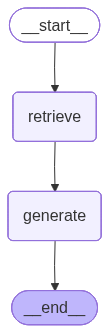

In [ ]:
from IPython.display import Image, display

builder = StateGraph(State)

# Nodes
builder.add_node("retrieve", retrieve)
builder.add_node("generate", generate)

# Edges: START → retrieve → generate → END
builder.add_edge(START, "retrieve")
builder.add_edge("retrieve", "generate")
builder.add_edge("generate", END)

# Compile
graph = builder.compile()

# Visualise
display(Image(graph.get_graph().draw_mermaid_png()))

## Example Run

Let's try to look for this painting

https://miamiuniversityartmuseum.omeka.net/items/show/1969

In [ ]:
question = {"question":" Are there any paul cadmus paintings in the collection?"}
response = graph.invoke(question)
print(response["generation"].content)

---RETRIEVE---
{'id': '2009.13', 'title': 'The Guitarist', 'creator': 'Paul Cadmus', 'date': '1969', 'medium': None, 'format': 'Painting', 'subject': 'Modern & Contemporary-Paintings-20th C. & Later', 'donor': 'Bequest of Robert E. White, Jr.', 'citation': 'Paul Cadmus, “The Guitarist,”Richard and Carole Cocks Art Museum at Miami University, accessed July 6, 2025,https://miamiuniversityartmuseum.omeka.net/items/show/1969.', 'tags': [], 'collection_link': 'https://miamiuniversityartmuseum.omeka.net/items/show/1969'}
---GENERATE---
Yes. The collection includes Paul Cadmus's painting "The Guitarist" (1969), showing his model Jon Anderson seated in his underwear playing the guitar in a room with a shelf and other objects.


In [ ]:
question = {"question":"Are there any artworks that are about a person playing a stringed instrument"}
response = graph.invoke(question)
print(response["generation"].content)

---RETRIEVE---
{'id': '2009.13', 'title': 'The Guitarist', 'creator': 'Paul Cadmus', 'date': '1969', 'medium': None, 'format': 'Painting', 'subject': 'Modern & Contemporary-Paintings-20th C. & Later', 'donor': 'Bequest of Robert E. White, Jr.', 'citation': 'Paul Cadmus, “The Guitarist,”Richard and Carole Cocks Art Museum at Miami University, accessed July 6, 2025,https://miamiuniversityartmuseum.omeka.net/items/show/1969.', 'tags': [], 'collection_link': 'https://miamiuniversityartmuseum.omeka.net/items/show/1969'}
---GENERATE---
Yes. Examples include The Guitarist (Paul Cadmus), Violin Player (William Verplanck Birney), Lady with a Lute (Hugo Ballin, 1905), The Musician (Cellist Applauding Gershwin) (John P. Rettig), Das Volkslied (F. Rengan) showing a woman with a harp, and Spanish Gypsies (T. Martin) with a guitarist.


___


# Agents

## SQL + Vector Hybrid Retrieval

Not every question needs semantic search. Some are better answered by exact SQL queries.

- **"How many paintings are in the collection?"** → SQL is faster and exact
- **"Art about loneliness and solitude"** → Vector captures semantic meaning

We'll build a **routing agent** that uses the LLM to classify each question and pick the right retrieval path.

## Creating an in-memory SQl server

In [ ]:
# Load the same art data into an in-memory SQLite database
conn = sqlite3.connect(":memory:")
cur = conn.cursor()
cur.execute("""
    CREATE TABLE artworks (
        title TEXT, identifier TEXT, subject TEXT, description TEXT,
        creator TEXT, format TEXT, date TEXT, medium TEXT, donor TEXT
    )
""")
for art in data:
    cur.execute(
        "INSERT INTO artworks VALUES (?,?,?,?,?,?,?,?,?)",
        tuple(art.get(k) for k in
              ["Title","Identifier","Subject","Description","Creator","Format","Date","Medium","Donor"])
    )
conn.commit()
print(f"Loaded {cur.execute('SELECT COUNT(*) FROM artworks').fetchone()[0]} artworks into SQLite")

Loaded 2333 artworks into SQLite


In [ ]:
# Example SQL query to find artworks by Paul Cadmus
cur.execute("SELECT title, creator, date FROM artworks WHERE creator LIKE '%Cadmus%'")
cur.fetchall()

[('The Guitarist', 'Paul Cadmus', '1969')]

### Adding a Router

We'll add a **router node** to the graph that classifies the user's question:
- If the question is about specific structured fields (creator, date, format, subject) → route to **SQL**
- If the question is about themes, moods, or visual descriptions → route to **vector search**

The LLM itself decides which path to take.

In [19]:
# The LLM itself decides whether to use SQL or vector search
# This is an "agent" pattern — the model routes based on the question's intent
def route_question(state):
    """Use the LLM to classify the query as sql or vector."""
    router_prompt = """You are a router for an art museum database. Given a user question, decide the retrieval method.

    Return "sql" if the question asks for specific structured data like:
    - A specific artist/creator name
    - A specific date or time period
    - A count or list filtered by exact fields (format, subject, donor)

    Return "vector" if the question is about:
    - Themes, moods, or abstract concepts
    - Visual descriptions or artistic style
    - Anything requiring semantic understanding

    Respond with ONLY "sql" or "vector".

    Question: {question}"""
    #----#
    result = llm.invoke([HumanMessage(content=router_prompt.format(question=state["question"]))])
    route = result.content.strip().lower()
    if route not in ("sql", "vector"):
        route = "vector"  # default fallback
    print(f"---ROUTE: {route}---")
    return {"route": route}

In [22]:
def sql_retrieve(state):
    """Generate and execute a SQL query against the artworks table."""
    print("---SQL RETRIEVE---")
    sql_prompt = """You are a SQL assistant. Given a user question about an art museum collection,
write a SQLite SELECT query against this table:

artworks(title, identifier, subject, description, creator, format, date, medium, donor)

Return ONLY the SQL query, nothing else.

Question: {question}"""
    result = llm.invoke([HumanMessage(content=sql_prompt.format(question=state["question"]))])
    query = result.content.strip().strip("`").replace("sql\n", "").strip()
    print(f"SQL: {query}")
    try:
        rows = cur.execute(query).fetchall()
        cols = [desc[0] for desc in cur.description]
        docs_text = "\n".join(
            ", ".join(f"{c}: {v}" for c, v in zip(cols, row)) for row in rows[:10]
        )
    except Exception as e:
        docs_text = f"SQL error: {e}"
    print(docs_text)
    return {"documents": [Document(page_content=docs_text)], "sql_query": query}

In [25]:
def decide_route(state):
    return "sql_retrieve" if state["route"] == "sql" else "retrieve"

builder = StateGraph(State)
builder.add_node("route_question", route_question)
builder.add_node("retrieve", retrieve)
builder.add_node("sql_retrieve", sql_retrieve)
builder.add_node("generate", generate)

builder.add_edge(START, "route_question")
builder.add_conditional_edges(
    "route_question",
    decide_route,
    {"sql_retrieve": "sql_retrieve", "retrieve": "retrieve"}
)
builder.add_edge("retrieve", "generate")
builder.add_edge("sql_retrieve", "generate")
builder.add_edge("generate", END)

routing_graph = builder.compile()
display(Image(routing_graph.get_graph().draw_mermaid_png()))

NameError: name 'StateGraph' is not defined

### Test: SQL-routed query

In [18]:
response = routing_graph.invoke({"question": "How many objects in total are in the collection?"})
print(response["generation"].content)

NameError: name 'routing_graph' is not defined

In [ ]:
response = routing_graph.invoke({"question": "How many objects were donated by the same donor?"})
print(response["generation"].content)

---ROUTE: sql---
---SQL RETRIEVE---
SQL: SELECT donor, COUNT(*) AS objects_donated
FROM artworks
GROUP BY donor
HAVING COUNT(*) > 1
ORDER BY objects_donated DESC;
donor: None, objects_donated: 845
donor: Gift of Walter I. Farmer, objects_donated: 225
donor: Gift of Ralph ('65) and Barbara Drake ('68) Bresler, objects_donated: 118
donor: Bequest of Dr. Robert E. Gregg, objects_donated: 116
donor: Gift of Edna M. Kelly, objects_donated: 81
donor: Gift of Larry Huston Family in honor of their son, Eric J. Huston, 2010, objects_donated: 51
donor: Gift of Jeffrey L. Horrell '75 and Rodney F. Rose, objects_donated: 47
donor: Gift of Charles M. Messer, objects_donated: 43
donor: Gifted by Richard and Carole Cocks, objects_donated: 42
donor: Gift of Ralph and Barbara Bresler, objects_donated: 42
---GENERATE---
Two donors each donated the same number of objects: 42. Those donors are "Gifted by Richard and Carole Cocks" and "Gift of Ralph and Barbara Bresler."


### Test: Vector-routed query

In [ ]:
response = routing_graph.invoke({"question": "Art that depicts loneliness or solitude"})
print(response["generation"].content)

---ROUTE: vector---
---RETRIEVE---
{'id': '2024.18', 'title': 'Desolate', 'creator': 'Claes Oldenburg (American, b. Sweden 1929)', 'date': '1972', 'medium': 'Offset lithograph process on paper with mechanical tints', 'format': 'PrintImage Size: 9 3/4 inches x 8 inches', 'subject': 'Graphic Arts-Prints', 'donor': "Gift of Jeffrey L. Horrell '75 and Rodney F. Rose", 'citation': 'Claes Oldenburg (American, b. Sweden 1929), “Desolate,”Richard and Carole Cocks Art Museum at Miami University, accessed July 6, 2025,https://miamiuniversityartmuseum.omeka.net/items/show/20706.', 'tags': ['20th Century', 'African Oceanic and New World Cultures', 'African Oceanic and New World Cultures-North America', 'American', 'Chair', 'Claes Oldenburg', 'Couch', 'Desolate', 'European', 'Graphic Arts', 'Graphic Arts-Prints', 'Lithograph', 'Mechanical tints', 'North American', 'Paper', 'Print', 'Sofa', 'Sweden', 'United States'], 'collection_link': 'https://miamiuniversityartmuseum.omeka.net/items/show/20706'}


# LLM Evals

Evaluating RAG systems is tricky. We need to measure:
- **Accuracy**: does the model answer correctly?
- **Latency**: how fast is the response?
- **Cost**: how many tokens are we burning?

A key challenge: some questions are **deterministic** (one right answer) and some are **non-deterministic** (many valid answers). Our golden set includes both types.

In [ ]:
with open("data/golden_set.json") as f:
    golden_set = json.load(f)

print(f"Golden set: {len(golden_set)} questions")
print(f"  Deterministic:     {sum(1 for q in golden_set if q['type'] == 'deterministic')}")
print(f"  Non-deterministic: {sum(1 for q in golden_set if q['type'] == 'non-deterministic')}")

print(golden_set[0])
print(golden_set[9])

Golden set: 10 questions
  Deterministic:     5
  Non-deterministic: 5
{'question': 'How many paintings are in the collection?', 'gold_answer': 'There are 664 paintings in the collection.', 'type': 'deterministic'}
{'question': 'What can you tell me about the ancient Greek and Roman artifacts?', 'gold_answer': 'The collection includes 255 ancient Greek and Roman artifacts such as vessels, cups, pyxides, and bronze objects, dating from circa 850 BCE to 300 CE.', 'type': 'non-deterministic'}


## Run RAG on the Golden Set

We run every question through our simple RAG graph and record the generated answer + latency.

In [ ]:
# Run every golden-set question through the RAG pipeline and record answer + latency
import time

results = []
for item in golden_set:
    start = time.time()
    response = routing_graph.invoke({"question": item["question"]})
    elapsed = time.time() - start
    results.append({
        "question": item["question"],
        "gold_answer": item["gold_answer"],
        "type": item["type"],
        "generated_answer": response["generation"].content,
        "route": response["route"],
        "sql_query": response.get("sql_query"),
        "retrieved_docs": "\n---\n".join(doc.page_content for doc in response["documents"]),
        "latency": round(elapsed, 2),
    })

results_df = pd.DataFrame(results)
results_df[["question", "type", "route", "sql_query", "generated_answer", "latency"]]

---ROUTE: sql---
---SQL RETRIEVE---
SQL: SELECT COUNT(*) FROM artworks WHERE lower(format) LIKE '%paint%' OR lower(medium) LIKE '%paint%';
COUNT(*): 664
---GENERATE---
---ROUTE: sql---
---SQL RETRIEVE---
SQL: SELECT COUNT(*) AS count FROM artworks WHERE creator = 'Ireland Belleek Pottery';
count: 117
---GENERATE---
---ROUTE: sql---
---SQL RETRIEVE---
SQL: SELECT medium FROM artworks WHERE creator = 'Adja Yunkers' AND title = 'Untitled III';

---GENERATE---
---ROUTE: sql---
---SQL RETRIEVE---
SQL: SELECT COUNT(*) FROM artworks WHERE donor = 'Walter I. Farmer';
COUNT(*): 0
---GENERATE---
---ROUTE: sql---
---SQL RETRIEVE---
SQL: SELECT DISTINCT title FROM artworks WHERE lower(creator) LIKE '%paul cadmus%' AND (lower(format) LIKE '%paint%' OR lower(medium) LIKE '%paint%' OR lower(description) LIKE '%paint%');
title: The Guitarist
---GENERATE---
---ROUTE: sql---
---SQL RETRIEVE---
SQL: SELECT * FROM artworks
WHERE (
  lower(subject) LIKE '%playing%' OR lower(subject) LIKE '%plays%' OR lower

,question,type,route,sql_query,generated_answer,latency
0,How many paintings are in the collection?,deterministic,sql,None,There are 664 paintings in the collection. Thi...,8.50
1,How many artworks did Ireland Belleek Pottery ...,deterministic,sql,None,The provided context does not list any artwork...,14.82
2,What medium did Adja Yunkers use for 'Untitled...,deterministic,sql,None,I don’t have the retrieved collection document...,8.57
3,How many artworks were donated by Walter I. Fa...,deterministic,sql,None,"According to the provided context, 0 artworks ...",9.52
4,Is there a Paul Cadmus painting in the collect...,deterministic,sql,None,"The collection includes a work titled ""The Gui...",15.33
5,What artworks depict someone playing a musical...,non-deterministic,sql,None,Artworks showing someone playing a musical ins...,23.68
6,Describe the African art in the collection.,non-deterministic,vector,None,The African holdings feature numerous Kuba raf...,9.58
7,What themes are represented in the modern and ...,non-deterministic,vector,None,The works primarily explore abstraction and mo...,7.97
8,Are there any artworks that evoke loneliness o...,non-deterministic,vector,None,"Yes. Claes Oldenburg’s 1972 print ""Desolate"" e...",6.21
9,What can you tell me about the ancient Greek a...,non-deterministic,vector,None,The holdings include Ancient Greek work such a...,8.65


## LLM as a Judge

We use a strong LLM to grade each answer on two criteria:
- **Helpfulness**: Is the answer relevant and concise to the question?
- **Correctness**: Does the answer match the gold (expected) answer factually?

For **deterministic** questions, correctness is straightforward — did it get the number right?  
For **non-deterministic** questions, this is where LLM-as-judge really earns its keep.

In [ ]:
# This prompt turns the LLM into a grader (LLM-as-judge)
# Correctness: does it match the gold answer factually?

correctness_prompt = """You are a teacher grading a quiz.

Given QUESTION, GROUND TRUTH ANSWER, and STUDENT ANSWER, evaluate:
1. The student answer is factually accurate compared to the ground truth
2. The student answer does not contain statements that conflict with the ground truth
3. The student answer may contain more information than the ground truth, as long as it is factually accurate

QUESTION: {question}
GROUND TRUTH ANSWER: {gold_answer}
STUDENT ANSWER: {answer}

Output "Correctness: True" if the answer is factually correct, or "Correctness: False" if not.
Then explain your reasoning step-by-step."""

### Run LLM-as-Judge (Concurrent)

We call the judge LLM directly for each question — two calls per question (helpfulness + correctness), run concurrently with `asyncio`.

In [ ]:
import asyncio

async def run_judges(results):
    tasks = []
    task_labels = []
    for i, r in enumerate(results):
        c_prompt = correctness_prompt.format(
            question=r["question"], gold_answer=r["gold_answer"], answer=r["generated_answer"]
        )
        tasks.append(asyncio.to_thread(judge_one_sync, client, c_prompt))
        task_labels.append((i, "correctness"))

    responses = await asyncio.gather(*tasks)
    return list(zip(task_labels, responses))

def judge_one_sync(client, prompt_text, model="gpt-5-mini-2025-08-07"):
    response = client.responses.create(model=model, input=prompt_text)
    return response.output_text

start = time.time()
judge_results_raw = await run_judges(results)
print(f"Judged {len(results)} questions in {time.time() - start:.1f}s")

# Parse verdicts — store full response and boolean flag
for (q_idx, judge_type), text in judge_results_raw:
    first_line = text.split("\n")[0]
    results[q_idx]["correctness_response"] = text
    results[q_idx]["correctness"] = "True" in first_line

results_df = pd.DataFrame(results)
results_df[["question", "type", "route", "correctness", "latency"]]

Judged 10 questions in 11.9s


,question,type,route,correctness,latency
0,How many paintings are in the collection?,deterministic,sql,True,8.50
1,How many artworks did Ireland Belleek Pottery ...,deterministic,sql,False,14.82
2,What medium did Adja Yunkers use for 'Untitled...,deterministic,sql,False,8.57
3,How many artworks were donated by Walter I. Fa...,deterministic,sql,False,9.52
4,Is there a Paul Cadmus painting in the collect...,deterministic,sql,False,15.33
5,What artworks depict someone playing a musical...,non-deterministic,sql,True,23.68
6,Describe the African art in the collection.,non-deterministic,vector,True,9.58
7,What themes are represented in the modern and ...,non-deterministic,vector,True,7.97
8,Are there any artworks that evoke loneliness o...,non-deterministic,vector,True,6.21
9,What can you tell me about the ancient Greek a...,non-deterministic,vector,False,8.65


In [ ]:
results_df = pd.DataFrame(results)
results_df[["question", "generated_answer", "gold_answer", "type", "route", "sql_query", "retrieved_docs", "correctness", "correctness_response", "latency"]]

,question,generated_answer,gold_answer,type,route,sql_query,retrieved_docs,correctness,correctness_response,latency
0,How many paintings are in the collection?,There are 664 paintings in the collection. Thi...,There are 664 paintings in the collection.,deterministic,sql,None,COUNT(*): 664,True,Correctness: True\n\nReasoning:\n1. The ground...,8.50
1,How many artworks did Ireland Belleek Pottery ...,The provided context does not list any artwork...,Ireland Belleek Pottery created 117 works in t...,deterministic,sql,None,count: 117,False,Correctness: False\n\nReasoning:\n1. The groun...,14.82
2,What medium did Adja Yunkers use for 'Untitled...,I don’t have the retrieved collection document...,Adja Yunkers used etching and screen print pro...,deterministic,sql,None,,False,Correctness: False\n\nReasoning:\n1. The groun...,8.57
3,How many artworks were donated by Walter I. Fa...,"According to the provided context, 0 artworks ...",Walter I. Farmer donated 237 artworks to the c...,deterministic,sql,None,COUNT(*): 0,False,Correctness: False\n\nReasoning:\n1. The groun...,9.52
4,Is there a Paul Cadmus painting in the collect...,"The collection includes a work titled ""The Gui...",Yes. 'The Guitarist' (1969) by Paul Cadmus.,deterministic,sql,None,title: The Guitarist,False,Correctness: False\n\nReasoning:\n- Ground tru...,15.33
5,What artworks depict someone playing a musical...,Artworks showing someone playing a musical ins...,The collection includes 'The Guitarist' by Pau...,non-deterministic,sql,None,"title: Plate, identifier: 1986.99, subject: Fu...",True,Correctness: True\n\nReasoning:\n- The student...,23.68
6,Describe the African art in the collection.,The African holdings feature numerous Kuba raf...,The collection includes works from various Afr...,non-deterministic,vector,None,"Title: Figural Door Lock with Crosspiece, Bama...",True,Correctness: True\n\nReasoning:\n- The ground ...,9.58
7,What themes are represented in the modern and ...,The works primarily explore abstraction and mo...,The modern and contemporary paintings cover a ...,non-deterministic,vector,None,Title: Moderne\nCreator: Tom Bacher\nDate: 199...,True,Correctness: True\n\nReasoning:\n1. The ground...,7.97
8,Are there any artworks that evoke loneliness o...,"Yes. Claes Oldenburg’s 1972 print ""Desolate"" e...",Several artworks in the collection depict soli...,non-deterministic,vector,None,Title: Desolate\nCreator: Claes Oldenburg (Ame...,True,Correctness: True\n\nReasoning:\n- The ground ...,6.21
9,What can you tell me about the ancient Greek a...,The holdings include Ancient Greek work such a...,The collection includes 255 ancient Greek and ...,non-deterministic,vector,None,Title: Roman Amphora\nCreator: Unknown\nDate: ...,False,Correctness: False\n\nReasoning:\n- The ground...,8.65


In [ ]:
summary = results_df.groupby("type").agg(
    count=("question", "count"),
    correctness_rate=("correctness", "mean"),
    avg_latency=("latency", "mean"),
).round(2)

print("=== Eval Summary by Question Type ===\n")
print(summary.to_string())
print(f"\nOverall Correctness: {results_df['correctness'].mean():.0%}")
print(f"Average Latency:     {results_df['latency'].mean():.2f}s")

=== Eval Summary by Question Type ===

                   count  correctness_rate  avg_latency
type                                                   
deterministic          5               0.2        11.35
non-deterministic      5               0.8        11.22

Overall Correctness: 50%
Average Latency:     11.28s


## Making the model Better

In [ ]:
routing_graph.invoke({"question": "What medium did Adja Yunkers use for 'Untitled III'?"})

---ROUTE: sql---
---SQL RETRIEVE---
SQL: SELECT medium FROM artworks WHERE creator = 'Adja Yunkers' AND title = 'Untitled III';

---GENERATE---


{'messages': [],
 'route': 'sql',
 'documents': [Document(metadata={}, page_content='')],
 'question': "What medium did Adja Yunkers use for 'Untitled III'?",
 'generation': AIMessage(content='I don’t have any object records or details in the provided context, so I can’t determine the medium of Adja Yunkers’ "Untitled III." Please provide the work’s catalogue entry or an image/description, and I’ll identify the medium.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 254, 'prompt_tokens': 106, 'total_tokens': 360, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 192, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DQb9GGbebFyMDOr0EM60lrzMpEV3w', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--

In [ ]:
cur.execute("SELECT medium FROM artworks WHERE creator = 'Adja Yunkers' AND title = 'Untitled III'")
cur.fetchall()

[]

In [ ]:
def sql_retrieve(state):
    """Generate and execute a SQL query against the artworks table."""
    print("---SQL RETRIEVE---")
    sql_prompt = """You are a SQL assistant. Given a user question about an art museum collection,
write a SQLite SELECT query against this table:

artworks(title, identifier, subject, description, creator, format, date, medium, donor)

Return ONLY the SQL query, nothing else.

Question: {question}"""
    result = llm.invoke([HumanMessage(content=sql_prompt.format(question=state["question"]))])
    query = result.content.strip().strip("`").replace("sql\n", "").strip()
    print(f"SQL: {query}")
    try:
        rows = cur.execute(query).fetchall()
        cols = [desc[0] for desc in cur.description]
        docs_text = "\n".join(
            ", ".join(f"{c}: {v}" for c, v in zip(cols, row)) for row in rows[:10]
        )
    except Exception as e:
        docs_text = f"SQL error: {e}"
    print(docs_text)
    return {"documents": [Document(page_content=docs_text)], "sql_query": query}

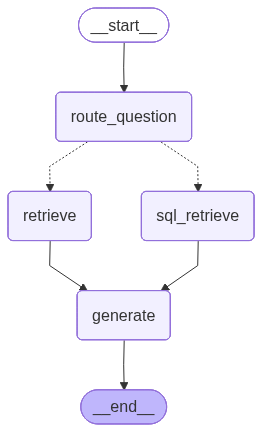

In [ ]:
def decide_route(state):
    return "sql_retrieve" if state["route"] == "sql" else "retrieve"

builder = StateGraph(State)
builder.add_node("route_question", route_question)
builder.add_node("retrieve", retrieve)
builder.add_node("sql_retrieve", sql_retrieve)
builder.add_node("generate", generate)

builder.add_edge(START, "route_question")
builder.add_conditional_edges(
    "route_question",
    decide_route,
    {"sql_retrieve": "sql_retrieve", "retrieve": "retrieve"}
)
builder.add_edge("retrieve", "generate")
builder.add_edge("sql_retrieve", "generate")
builder.add_edge("generate", END)

routing_graph = builder.compile()
display(Image(routing_graph.get_graph().draw_mermaid_png()))

In [ ]:
routing_graph.invoke({"question": "What medium did Adja Yunkers use for 'Untitled III'?"})

---ROUTE: sql---
---SQL RETRIEVE---
SQL: SELECT medium FROM artworks WHERE creator LIKE '%Adja Yunkers%' AND title LIKE '%Untitled III%';
medium: Etching and screen print process on paper
---GENERATE---


{'messages': [],
 'route': 'sql',
 'documents': [Document(metadata={}, page_content='medium: Etching and screen print process on paper')],
 'question': "What medium did Adja Yunkers use for 'Untitled III'?",
 'generation': AIMessage(content='Adja Yunkers used etching and a screen print process on paper for "Untitled III."', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 94, 'prompt_tokens': 117, 'total_tokens': 211, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DQbAK8Q8KeLVxwopEQrwQfvEV9d0w', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d540f-0498-7302-8682-4fd739a8969f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input

____

## Alternative: Batch API (50% Cheaper)

The concurrent approach above works, but at scale (hundreds or thousands of evals) it gets expensive. The **OpenAI Batch API** is the cost-saving alternative:
- Send all requests at once as a JSONL file
- **50% discount** on token costs
- Results come back within 24 hours (usually much faster)
- Trade-off: not real-time, but perfect for nightly eval runs

In [ ]:
batch_requests = []
for i, r in enumerate(results):
    # Correctness judge
    batch_requests.append({
        "custom_id": f"q{i}__correctness",
        "method": "POST",
        "url": "/v1/responses",
        "body": {
            "model": "modelname",
            "input": correctness_prompt.format(
                question=r["question"],
                gold_answer=r["gold_answer"],
                answer=r["generated_answer"],
            ),
        },
    })

# Write JSONL
with open("data/judge_batch.jsonl", "w") as f:
    for req in batch_requests:
        f.write(json.dumps(req) + "\n")

print(f"Wrote {len(batch_requests)} judge requests to data/judge_batch.jsonl")

## Submit Batch to OpenAI

In [ ]:
# batch_file = client.files.create(
#     file=open("data/judge_batch.jsonl", "rb"),
#     purpose="batch"
# )
# batch_job = client.batches.create(
#     input_file_id=batch_file.id,
#     endpoint="/v1/responses",
#     completion_window="24h",
# )
# print(f"Batch ID: {batch_job.id}")
# print(f"Status:   {batch_job.status}")

## Check Batch Status & Download Results

Re-run this cell until status is `completed`.

In [ ]:
# batch_job = client.batches.retrieve(batch_job.id)
# print(f"Status: {batch_job.status}")

# if batch_job.status == "completed":
#     content = client.files.content(batch_job.output_file_id)
#     with open("data/judge_results.jsonl", "wb") as f:
#         f.write(content.read())
#     print("Results downloaded to data/judge_results.jsonl")

## Parse Judge Results

Extract the True/False verdicts from each judge response and build a summary table.

In [ ]:
# judge_scores = {}

# with open("data/judge_results.jsonl") as f:
#     for line in f:
#         record = json.loads(line)
#         custom_id = record["custom_id"]
#         # Extract the response text
#         output_text = record["response"]["body"]["output"][0]["content"][0]["text"]

#         q_idx, judge_type = custom_id.split("__")
#         q_num = int(q_idx.replace("q", ""))

#         if q_num not in judge_scores:
#             judge_scores[q_num] = {}

#         # Parse True/False from response
#         judge_scores[q_num]["correctness_response"] = output_text
#         judge_scores[q_num]["correctness"] = "True" in output_text.split("\n")[0]

# # Merge with results
# for i, r in enumerate(results):
#     r["correctness_response"] = judge_scores.get(i, {}).get("correctness_response", None)
#     r["correctness"] = judge_scores.get(i, {}).get("correctness", None)

# results_df = pd.DataFrame(results)
# results_df[["question", "type", "route", "correctness", "latency"]]